In [2]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

In [3]:
percent_missing = 100*df.isnull().mean()
percent_missing


Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

In [4]:
df.dropna(axis=0)


,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [5]:
df.dropna(axis=1)


,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


In [6]:
df.dropna(thresh=5)


,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


In [7]:
df.dropna(subset=['Age'])


,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


In [8]:
df_drop = df.drop(columns = 'Blood Type')
df_drop


,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [9]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled


,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [10]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [11]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


In [12]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [13]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


In [14]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: ylabel='Height'>

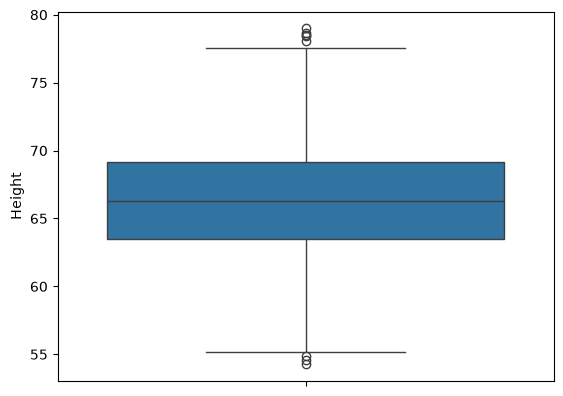

In [17]:
import seaborn as sns
sns.boxplot(df2['Height'])


<Axes: ylabel='Height'>

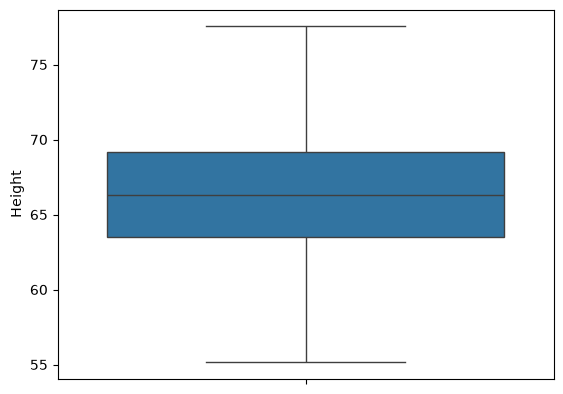

In [19]:
import numpy as np
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Height'] >= lower_bound)
 & (df2['Height'] <= upper_bound)]
sns.boxplot(clean_data['Height'])


<Axes: ylabel='Weight'>

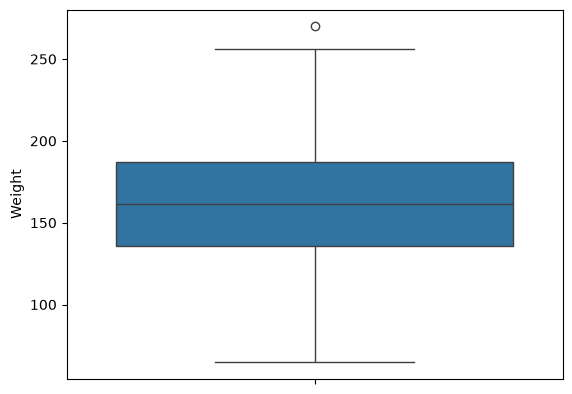

In [20]:
sns.boxplot(df2['Weight'])


C:\Users\MSII\AppData\Local\Temp\ipykernel_26308\1093592084.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\MSII\AppData\Local\Temp\ipykernel_26308\1093592084.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


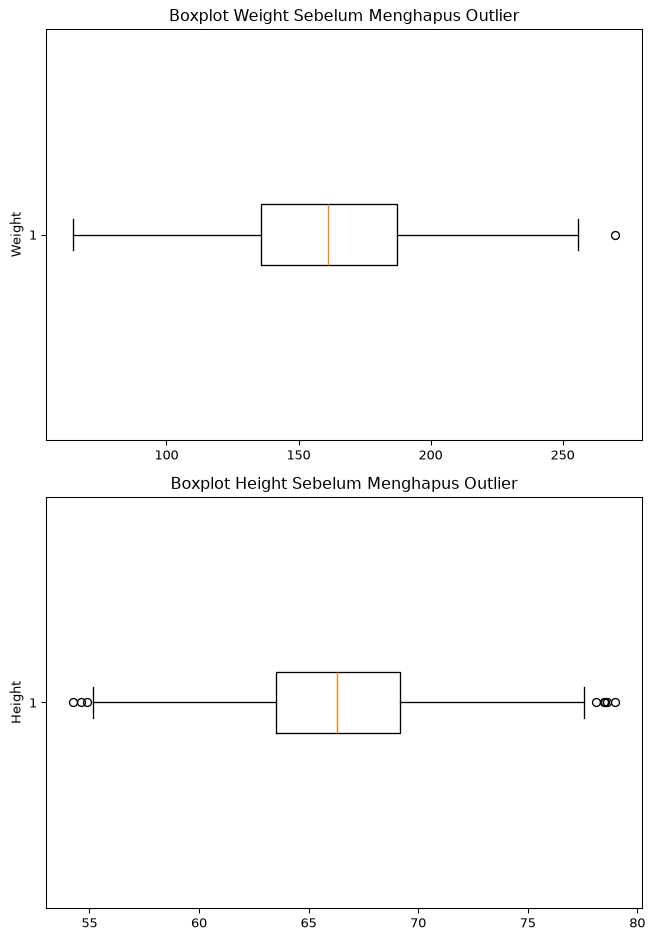

C:\Users\MSII\AppData\Local\Temp\ipykernel_26308\1093592084.py:74: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\MSII\AppData\Local\Temp\ipykernel_26308\1093592084.py:74: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


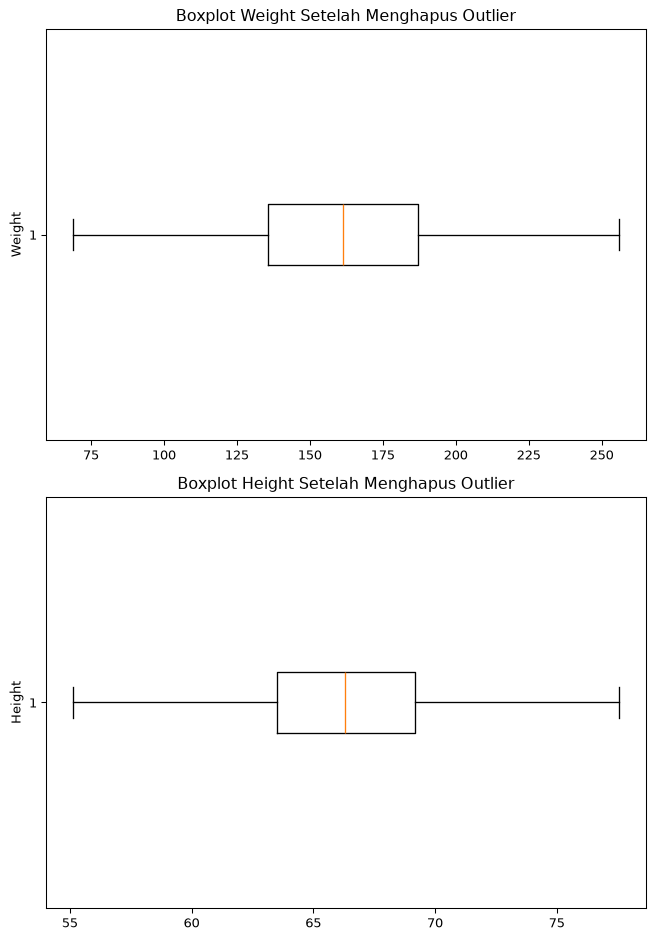

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Membuat daftar kolom yang ingin dianalisis
columns_to_plot = ['Weight', 'Height']

# Memastikan kolom ada di dataset
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

# Membuat boxplot sebelum menghapus outlier
fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

# Jika hanya ada satu kolom
if len(columns_to_plot) == 1:
    axs = [axs]

# Membuat boxplot
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)
    axs[i].set_title(f'Boxplot {col} Sebelum Menghapus Outlier')

plt.tight_layout()
plt.show()


# Fungsi untuk menghapus outlier secara berurutan
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()

    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) &
            (df_cleaned[col] <= upper_bound)
        ]

    return df_cleaned


# Terapkan fungsi untuk menghapus outlier dari Height dan Weight
clean_data = remove_outliers_sequentially(
    df2,
    ['Height', 'Weight']
)


# Plot boxplots setelah menghapus outlier
columns_to_plot = ['Weight', 'Height']

fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

# Jika hanya ada satu kolom
if len(columns_to_plot) == 1:
    axs = [axs]

# Membuat boxplot setelah outlier dihapus
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)
    axs[i].set_title(f'Boxplot {col} Setelah Menghapus Outlier')

plt.tight_layout()
plt.show()

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
# Memisahkan kolom numerik dan non-numerik
numeric_cols = clean_data.select_dtypes(include=[np.number]).columns # Ambil kolom
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns # Ambil k
rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric[:] 

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

In [ ]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

# Melihat jumlah missing value sebelum ditangani
print("Missing value sebelum:")
print(df.isnull().sum())

In [ ]:
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            nilai_pengganti = df[col].median()

            # Jika seluruh kolom kosong, gunakan 0
            if pd.isna(nilai_pengganti):
                nilai_pengganti = 0
        else:
            modus = df[col].mode()
            nilai_pengganti = modus.iloc[0] if not modus.empty else "Unknown"

        df[col] = df[col].fillna(nilai_pengganti)

# Semua kolom seharusnya menunjukkan 0
print("Missing value setelah:")
print(df.isnull().sum())

In [ ]:
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            nilai_pengganti = df[col].median()

            # Jika seluruh kolom kosong, gunakan 0
            if pd.isna(nilai_pengganti):
                nilai_pengganti = 0
        else:
            modus = df[col].mode()
            nilai_pengganti = modus.iloc[0] if not modus.empty else "Unknown"

        df[col] = df[col].fillna(nilai_pengganti)

# Semua kolom seharusnya menunjukkan 0
print("Missing value setelah:")
print(df.isnull().sum())

In [ ]:
def remove_outliers_sequentially(data, columns):
    df_cleaned = data.copy()

    for col in columns:
        q1 = df_cleaned[col].quantile(0.25)
        q3 = df_cleaned[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Hapus outliers; pertahankan nilai kosong jika ada
        mask = (
            df_cleaned[col].between(lower_bound, upper_bound)
            | df_cleaned[col].isna()
        )
        df_cleaned = df_cleaned[mask]

    return df_cleaned

clean_data = remove_outliers_sequentially(df2, columns_to_plot)

print("Jumlah baris sebelum:", len(df2))
print("Jumlah baris setelah:", len(clean_data))
print("Jumlah baris yang dihapus:", len(df2) - len(clean_data))

In [ ]:
# Boxplot setelah penanganan outliers
fig, axs = plt.subplots(3, 1, figsize=(8, 9), dpi=95)

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col].dropna(), vert=False)
    axs[i].set_ylabel(col)
    axs[i].set_title(f"{col} setelah penanganan")

plt.tight_layout()
plt.show()
#